In [1]:
from qiskit_metal import Dict, view
from qiskit_metal.designs import DesignPlanar
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.tlines.straight_path import RouteStraight
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
from qiskit_metal import MetalGUI

design = DesignPlanar()
design._chips["main"]["size"]["size_x"] = "9mm"
design._chips["main"]["size"]["size_y"] = "9mm"

# Resonator and feedline gap width (W) and center conductor width (S) from reference 2
design.variables["cpw_width"] = "15 um"  # S from reference 2
design.variables["cpw_gap"] = "9 um"  # W from reference 2

length = 2 # in mm

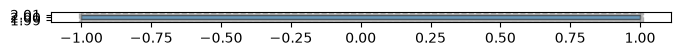

In [2]:
# Driven Lauchpad 1
x = f"-{length/2} mm"
y = "2.0mm"
launch_options = dict(
    chip="main", pos_x=x, pos_y=y, orientation="180", lead_length="30um", width = design.variables["cpw_width"], gap = design.variables["cpw_gap"], termination_gap = design.variables["cpw_gap"],
)
LP1 = OpenToGround(design, "LP1", options=launch_options)

# Driven Launchpad 2
x = f"{length/2}mm"
y = "2.0mm"
launch_options = dict(
    chip="main", pos_x=x, pos_y=y, orientation="0", lead_length="30um", width = design.variables["cpw_width"], gap = design.variables["cpw_gap"], termination_gap = design.variables["cpw_gap"],
)
LP2 = OpenToGround(design, "LP2", options=launch_options)

# Using path finder to connect the two launchpads
TL_LP1_LP2 = RoutePathfinder(
    design,
    "TL_LP1_LP2",
    options=dict(
        chip="main",
        trace_width="15um",
        trace_gap="9um",
        fillet="99um",
        hfss_wire_bonds=True,
        pin_inputs=Dict(
            start_pin=Dict(component="LP1", pin="open"),
            end_pin=Dict(component="LP2", pin="open"),
        ),
    ),
)

view(design)

In [3]:
from qiskit_metal.analyses.quantization import EPRanalysis

In [4]:
eig_qb = EPRanalysis(design, "hfss")
eig_qb.sim.setup.max_passes = 20
eig_qb.sim.setup.basis_order = 1
# example: update multiple settings
eig_qb.sim.setup_update(n_modes=2, max_delta_f=0.1, min_freq_ghz=1.1,)
eig_qb.sim._initialize_renderer()
eig_qb.sim.setup


NameError: name 'design' is not defined

In [5]:
eig_qb.sim.run_sim(name='test', components=['TL_LP1_LP2', 'LP1', 'LP2'])


INFO 10:57AM [connect_design]: 	Opened active design
	Design:    test_hfss [Solution type: Eigenmode]
INFO 10:57AM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 10:57AM [analyze]: Analyzing setup Setup
10:58AM 37s INFO [get_f_convergence]: Saved convergences to c:\Users\DELL\chip-design\metal-flow\hfss_eig_f_convergence.csv


('test_hfss', 'Setup')

In [5]:
eig_qb.sim.close()

NameError: name 'eig_qb' is not defined

In [6]:
del eig_qb

NameError: name 'eig_qb' is not defined